# Expected value is a number. It is not a decision.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/expected-value-calc/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/expected-value-calc/demo.ipynb)

**Day 157 of the FDE portfolio.**

Somebody asks which option to take, so you build the spreadsheet: probability
times payoff, one row per option, pick the biggest. That arithmetic is right and
the decision it produces can still be wrong, in four separate ways:

| § | |
|---|---|
| 1-2 | You typed the mode, and then evaluated a curve at its average |
| 3 | The higher expected value loses more often than it wins |
| 4-5 | The input everyone argues about is not the one that decides it |
| 6 | Repeat the bet and the average rises while you go broke |
| 7 | Sometimes the answer is to find out first - and that is priceable |

## 1. The decision

Build a tool, buy the vendor's, or do neither. Three-year horizon, four things
nobody knows. Ranges are P10 / most-likely / P90, which is what people can
actually give you.

In [1]:
from __future__ import annotations

import math
from typing import Dict

import numpy as np

RNG_SEED = 20260827
N = 200_000

# name: (P10, most-likely, P90, unit)
INPUTS = {
    "seats":        (12, 32, 90, "seats"),
    "hours_saved":  (0.4, 1.4, 3.0, "hours/seat/week"),
    "hourly_cost":  (45, 70, 95, "currency/hour"),
    "build_months": (3.0, 6.0, 15.0, "months"),
}

BUILD_TEAM_COST_PER_MONTH = 30_000.0
BUILD_MAINTENANCE_PER_YEAR = 45_000.0
BUY_ONBOARDING = 80_000.0
BUY_LICENCE_PER_SEAT_YEAR = 1_800.0
BUY_SEAT_CAP = 20.0
HORIZON = 3.0


def pert(rng, lo, mid, hi, n):
    """A beta on [lo, hi] peaked at mid - thin tails, unlike a triangular."""
    span = hi - lo
    mode = min(max((mid - lo) / span, 1e-6), 1 - 1e-6)
    c = 4.0
    return lo + rng.beta(1 + c * mode, 1 + c * (1 - mode), n) * span


def value(option, seats, hours_saved, hourly_cost, build_months):
    """Two ordinary nonlinearities: a vendor seat cap, and a build that
    earns nothing until it ships."""
    if option == "defer":
        return np.zeros_like(seats)
    if option == "buy":
        capped = np.minimum(seats, BUY_SEAT_CAP)
        return (capped * hours_saved * hourly_cost * 46.0 * HORIZON
                - (BUY_ONBOARDING + capped * BUY_LICENCE_PER_SEAT_YEAR * HORIZON))
    live = np.maximum(HORIZON - build_months / 12.0, 0.0)
    return (seats * hours_saved * hourly_cost * 46.0 * live
            - (build_months * BUILD_TEAM_COST_PER_MONTH
               + BUILD_MAINTENANCE_PER_YEAR * live))


rng = np.random.default_rng(RNG_SEED)
draws = {k: pert(rng, *v[:3], N) for k, v in INPUTS.items()}
OPTIONS = ("build", "buy", "defer")
sims = {o: value(o, **draws) for o in OPTIONS}

print(f"{'input':<15}{'P10':>8}{'typed':>8}{'P90':>8}   unit")
print("-" * 56)
for k, (lo, mid, hi, unit) in INPUTS.items():
    print(f"{k:<15}{lo:>8}{mid:>8}{hi:>8}   {unit}")

input               P10   typed     P90   unit
--------------------------------------------------------
seats                12      32      90   seats
hours_saved         0.4     1.4     3.0   hours/seat/week
hourly_cost          45      70      95   currency/hour
build_months        3.0     6.0    15.0   months


## 2. Two different averaging errors, and the famous one is smaller

**Error one:** the number typed into the cell is the *most-likely* value. For a
skewed range that is the mode, not the mean.

**Error two:** the flaw of averages proper - `f(E[x])` is not `E[f(x)]`. Measured
at the true input *means*, so error one cannot contaminate it.

In [2]:
mids = {k: v[1] for k, v in INPUTS.items()}
means = {k: float(draws[k].mean()) for k in INPUTS}

print("ERROR ONE - typed the mode, not the mean")
print(f"{'input':<15}{'typed':>9}{'actual mean':>14}{'shift':>9}")
print("-" * 50)
for k in INPUTS:
    print(f"{k:<15}{mids[k]:>9.2f}{means[k]:>14.2f}{means[k] - mids[k]:>+9.2f}")

at_mid = {o: float(value(o, **{k: np.array([mids[k]]) for k in mids})[0]) for o in OPTIONS}
at_mean = {o: float(value(o, **{k: np.array([means[k]]) for k in means})[0]) for o in OPTIONS}
true_ev = {o: float(sims[o].mean()) for o in OPTIONS}

print("\nERROR TWO - Jensen, measured at the input means")
print(f"{'option':<8}{'typed-mid':>13}{'at means':>13}{'true EV':>13}{'Jensen gap':>13}")
print("-" * 62)
for o in ("build", "buy"):
    print(f"{o:<8}{at_mid[o]:>13,.0f}{at_mean[o]:>13,.0f}{true_ev[o]:>13,.0f}"
          f"{at_mean[o] - true_ev[o]:>+13,.0f}")

whole = true_ev["build"] - at_mid["build"]
print(f"\nFor `build` the whole error is {whole:,.0f} and Jensen is "
      f"{at_mean['build'] - true_ev['build']:,.0f} of it.")
print("The famous nonlinearity effect is near zero here. Typing the mode is the")
print("entire problem - worth knowing, because the popular telling blames the curve.")

for o in ("build", "buy"):
    band = abs(at_mid[o]) * 0.05
    p = float(np.mean(np.abs(sims[o] - at_mid[o]) <= band))
    print(f"    P(outcome within 5% of the typed estimate for {o}) = {p:.1%}")

ERROR ONE - typed the mode, not the mean
input              typed   actual mean    shift
--------------------------------------------------
seats              32.00         38.36    +6.36
hours_saved         1.40          1.50    +0.10
hourly_cost        70.00         70.01    +0.01
build_months        6.00          7.01    +1.01

ERROR TWO - Jensen, measured at the input means
option      typed-mid     at means      true EV   Jensen gap
--------------------------------------------------------------
build          68,140      128,937      128,909          +27
buy            82,480      102,012       99,933       +2,079

For `build` the whole error is 60,769 and Jensen is 27 of it.
The famous nonlinearity effect is near zero here. Typing the mode is the
entire problem - worth knowing, because the popular telling blames the curve.
    P(outcome within 5% of the typed estimate for build) = 1.2%
    P(outcome within 5% of the typed estimate for buy) = 3.1%


## 3. The higher expected value loses more often than it wins

Both statements are true of the same numbers. Expected value ranks the mean, and
a mean is an average over futures - only one of which happens.

In [3]:
print(f"{'option':<8}{'expected value':>17}{'P10':>12}{'median':>12}{'P90':>12}{'P(loss)':>10}")
print("-" * 72)
for o in OPTIONS:
    s = sims[o]
    print(f"{o:<8}{s.mean():>17,.0f}{np.quantile(s, 0.1):>12,.0f}"
          f"{np.median(s):>12,.0f}{np.quantile(s, 0.9):>12,.0f}"
          f"{float(np.mean(s < 0)):>10.1%}")

p_build_wins = float(np.mean(sims["build"] > sims["buy"]))
print(f"\nbuild has {sims['build'].mean() - sims['buy'].mean():,.0f} more expected value")
print(f"and beats buy {p_build_wins:.1%} of the time.")
print("\nbuild carries a longer right tail that lifts its average while most draws land")
print("below buy. Which fact matters depends on whether the bet repeats - see below.")

option     expected value         P10      median         P90   P(loss)
------------------------------------------------------------------------
build             128,909    -148,303      84,671     469,637     34.8%
buy                99,933     -26,454      90,652     238,977     17.4%
defer                   0           0           0           0      0.0%

build has 28,976 more expected value
and beats buy 49.3% of the time.

build carries a longer right tail that lifts its average while most draws land
below buy. Which fact matters depends on whether the bet repeats - see below.


## 4-5. Which input decides it, and what would have to be true

A tornado moves one input P10 to P90 with the others held at their typed value.
Then the more useful question: at what value of each input does the
recommendation *flip*?

In [4]:
def gap_at(overrides: Dict[str, float]) -> float:
    args = {k: np.array([overrides.get(k, mids[k])]) for k in mids}
    return float(value("build", **args)[0] - value("buy", **args)[0])


print(f"{'input':<15}{'at P10':>13}{'at P90':>13}{'swing':>13}")
print("-" * 56)
rows = []
for k, (lo, _mid, hi, _u) in INPUTS.items():
    a, b = gap_at({k: lo}), gap_at({k: hi})
    rows.append((k, a, b, abs(b - a)))
rows.sort(key=lambda r: -r[3])
for k, a, b, sw in rows:
    print(f"{k:<15}{a:>+13,.0f}{b:>+13,.0f}{sw:>13,.0f}")
print(f"\n`{rows[0][0]}` swings it {rows[0][3] / rows[-1][3]:.0f}x more than `{rows[-1][0]}`.")
print("The hourly rate is what gets debated. Adoption is what decides it.")


def switch(k):
    lo, hi = INPUTS[k][0], INPUTS[k][2]
    if gap_at({k: lo}) * gap_at({k: hi}) > 0:
        return None
    for _ in range(200):
        m = (lo + hi) / 2
        if gap_at({k: lo}) * gap_at({k: m}) <= 0:
            hi = m
        else:
            lo = m
    return (lo + hi) / 2


print(f"\n{'input':<15}{'typed':>9}{'flips at':>11}{'distance':>11}")
print("-" * 48)
for k in INPUTS:
    s = switch(k)
    print(f"{k:<15}{mids[k]:>9.2f}{s:>11.2f}{s - mids[k]:>+11.2f}")
print("\nEvery flip sits inside the plausible range, and two are within a rounding")
print("error of the typed estimate. The decision is not 'build, by 29,000'. It is")
print("'build if adoption clears about 33 seats' - which somebody can go and check.")

input                 at P10       at P90        swing
--------------------------------------------------------
seats               -174,748     +639,320      814,068
build_months        +100,474     -358,782      459,256
hours_saved          -78,740      +88,700      167,440
hourly_cost          -46,540      +17,860       64,400

`seats` swings it 13x more than `hourly_cost`.
The hourly rate is what gets debated. Adoption is what decides it.

input              typed   flips at   distance
------------------------------------------------
seats              32.00      33.27      +1.27
hours_saved         1.40       1.62      +0.22
hourly_cost        70.00      81.13     +11.13
build_months        6.00       5.63      -0.37

Every flip sits inside the plausible range, and two are within a rounding
error of the typed estimate. The decision is not 'build, by 29,000'. It is
'build if adoption clears about 33 seats' - which somebody can go and check.


## 6. Positive expected value, and you still go broke

A gamble: 50% chance of ×1.5, otherwise ×0.6, staked on your whole bankroll.
The average multiplier is 1.05 per round. The growth a single run experiences is
the *geometric* mean, and it is below 1.

In [5]:
UP, DOWN, P_UP = 1.5, 0.6, 0.5
ensemble = P_UP * UP + (1 - P_UP) * DOWN
time_avg = math.exp(P_UP * math.log(UP) + (1 - P_UP) * math.log(DOWN))
print(f"average multiplier per round    {ensemble:.4f}   (positive expected value)")
print(f"growth a single run experiences {time_avg:.4f}   (it shrinks)")

kelly = (P_UP * (UP - 1) - (1 - P_UP) * (1 - DOWN)) / ((1 - DOWN) * (UP - 1))
print(f"\nstake maximising expected LOG wealth: {kelly:.0%}\n")


def run(fraction, rounds=250, n=20_000, seed=RNG_SEED + 5):
    r = np.random.default_rng(seed)
    wins = r.random((n, rounds)) < P_UP
    mult = np.where(wins, 1 + fraction * (UP - 1), 1 - fraction * (1 - DOWN))
    w = np.prod(mult, axis=1)
    return w.mean(), float(np.median(w)), float(np.mean(w < 0.01))


print(f"{'stake':>8}{'mean':>14}{'median':>13}{'lost 99%':>11}")
print("-" * 48)
for f in (1.0, 0.5, kelly, kelly / 2):
    m, med, ruin = run(f)
    med_s = f"{med:,.2f}" if med >= 0.01 else f"{med:.2e}"
    print(f"{f:>8.3f}{m:>14,.2f}{med_s:>13}{ruin:>11.1%}")

print("\nStaking everything is what maximising expected value per round tells you to do.")
print("The mean ends in the hundreds and the median ends at millionths of the stake.")
print("The average is carried by a vanishing set of paths nobody is on.")

average multiplier per round    1.0500   (positive expected value)
growth a single run experiences 0.9487   (it shrinks)

stake maximising expected LOG wealth: 25%

   stake          mean       median   lost 99%
------------------------------------------------
   1.000        507.47     1.91e-06      89.0%
   0.500        387.81         1.00       9.2%
   0.250         21.83         4.72       0.0%
   0.125          4.68         3.21       0.0%

Staking everything is what maximising expected value per round tells you to do.
The mean ends in the hundreds and the median ends at millionths of the stake.
The average is carried by a vanishing set of paths nobody is on.


## 7. What it is worth to find out first

Expected value of perfect information: what the decision would be worth if you
knew the answer, minus what it is worth now. It is the **ceiling** on any study,
pilot or spike - decidable *before* commissioning one.

In [6]:
stacked = np.vstack([sims[o] for o in OPTIONS])
best_known = max(sims[o].mean() for o in OPTIONS)
evpi = float(np.max(stacked, axis=0).mean()) - best_known
print(f"best option without information   {best_known:,.0f}")
print(f"if the future were known          {best_known + evpi:,.0f}")
print(f"EVPI                              {evpi:,.0f}   "
      f"({evpi / best_known:.0%} of the decision's value)")


def evppi(name, bins=40):
    """What learning ONE input is worth - which is what gets commissioned."""
    x = draws[name]
    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    idx = np.clip(np.digitize(x, edges[1:-1]), 0, bins - 1)
    total = 0.0
    for k in range(bins):
        m = idx == k
        if m.any():
            total += m.sum() * max(sims[o][m].mean() for o in OPTIONS)
    return float(total / len(x) - best_known)


print(f"\n{'learn this':<16}{'worth up to':>14}")
print("-" * 32)
parts = {k: evppi(k) for k in INPUTS}
for k, v in sorted(parts.items(), key=lambda kv: -kv[1]):
    print(f"{k:<16}{v:>14,.0f}")
print(f"\nThe parts sum to {sum(parts.values()):,.0f} against an EVPI of {evpi:,.0f}:")
print("information is not additive. The second study only pays where the first left")
print("the decision open.")
top, worst = max(parts, key=parts.get), min(parts, key=parts.get)
print(f"\nA study of `{top}` is worth up to {parts[top]:,.0f}. The same study of `{worst}`")
print(f"is worth {parts[worst]:,.0f} - it cannot repay a single afternoon. Both would be")
print("proposed in the same meeting with the same seriousness.")

best option without information   128,909
if the future were known          196,124
EVPI                              67,214   (52% of the decision's value)

learn this         worth up to
--------------------------------
seats                   51,054
build_months            25,077
hours_saved             15,021
hourly_cost                801

The parts sum to 91,952 against an EVPI of 67,214:
information is not additive. The second study only pays where the first left
the decision open.

A study of `seats` is worth up to 51,054. The same study of `hourly_cost`
is worth 801 - it cannot repay a single afternoon. Both would be
proposed in the same meeting with the same seriousness.


## The picture

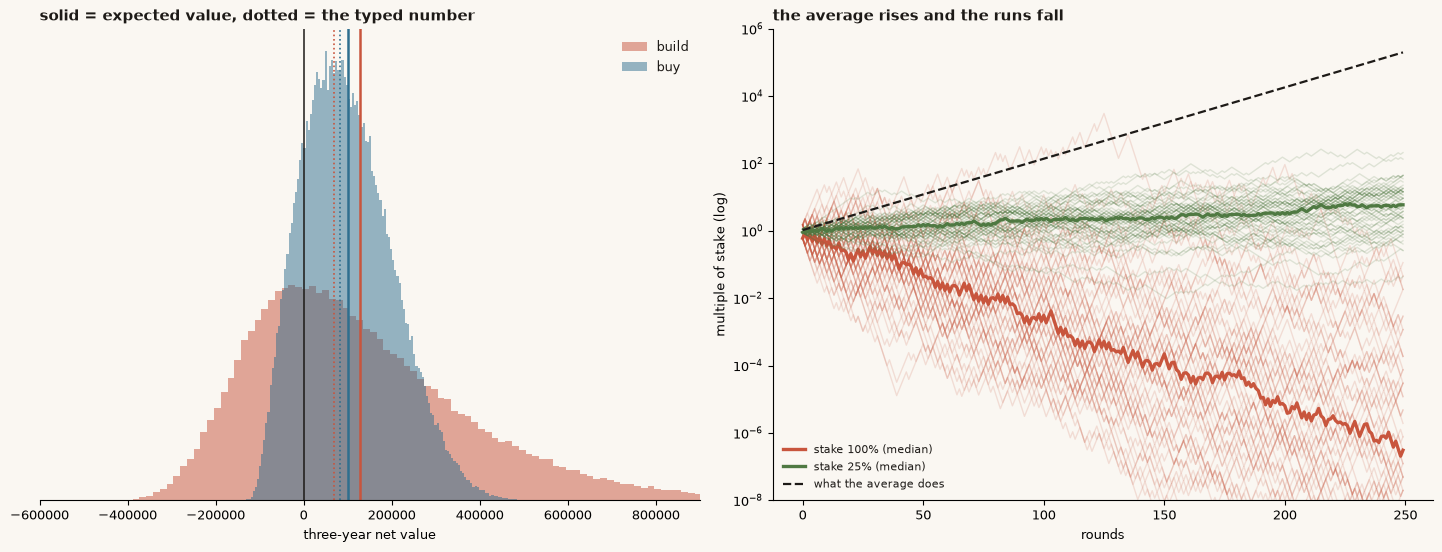

In [7]:
import matplotlib.pyplot as plt

INK, GRIDC, PAPER = "#1d1a17", "#e3ddd5", "#faf7f2"
ACCENT, COOL, GREEN = "#c8553d", "#2f6f8f", "#4f7942"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "text.color": INK, "font.size": 9})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.6))

for o, col in (("build", ACCENT), ("buy", COOL)):
    ax1.hist(sims[o], bins=140, alpha=0.5, color=col, label=o, density=True)
    ax1.axvline(sims[o].mean(), color=col, lw=1.8)
    ax1.axvline(at_mid[o], color=col, lw=1.2, ls=":")
ax1.axvline(0, color=INK, lw=1.1)
ax1.set_xlim(-600_000, 900_000)
ax1.set_yticks([])
ax1.set_xlabel("three-year net value")
ax1.legend(frameon=False)
ax1.set_title("solid = expected value, dotted = the typed number",
              loc="left", fontweight="bold")
for s in ("top", "right", "left"):
    ax1.spines[s].set_visible(False)

r = np.random.default_rng(RNG_SEED + 11)
for f, col in ((1.0, ACCENT), (kelly, GREEN)):
    wins = r.random((60, 250)) < P_UP
    mult = np.where(wins, 1 + f * (UP - 1), 1 - f * (1 - DOWN))
    paths = np.cumprod(mult, axis=1)
    ax2.plot(paths.T, color=col, alpha=0.16, lw=1)
    ax2.plot(np.median(paths, axis=0), color=col, lw=2.4, label=f"stake {f:.0%} (median)")
ax2.plot(np.cumprod(np.full(250, ensemble)), color=INK, lw=1.6, ls="--",
         label="what the average does")
ax2.set_yscale("log")
ax2.set_ylim(1e-8, 1e6)
ax2.set_xlabel("rounds")
ax2.set_ylabel("multiple of stake (log)")
ax2.legend(frameon=False, fontsize=8, loc="lower left")
ax2.set_title("the average rises and the runs fall", loc="left", fontweight="bold")
for s in ("top", "right"):
    ax2.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("notebook_ev.png", dpi=140, facecolor=PAPER)
plt.show()

## Try your own

Replace the ranges and the payoff. The two lines worth adding to any of these
models are the switching point and the EVPI - neither is more than a few lines,
and both change what the meeting is about.

In [8]:
# MY_INPUTS = {
#     "users":   (50, 200, 900, "users"),
#     "months":  (2.0, 4.0, 12.0, "months"),
# }
#
# def my_value(option, users, months):
#     if option == "a":
#         return users * 400.0 - months * 25_000.0
#     return np.full_like(users, 120_000.0)
#
# r = np.random.default_rng(0)
# d = {k: pert(r, *v[:3], 100_000) for k, v in MY_INPUTS.items()}
# out = {o: my_value(o, **d) for o in ("a", "b")}
# for o, s in out.items():
#     print(f"{o}: EV {s.mean():>12,.0f}   P(loss) {float(np.mean(s < 0)):.1%}")
# print(f"P(a beats b) = {float(np.mean(out['a'] > out['b'])):.1%}")

## What to carry out of the meeting

1. **Elicit ranges, not points.** P10 / most-likely / P90 is what people can give,
   and the middle of that range is not its mean.
2. **Simulate the payoff; never evaluate it at the averages.** Report the
   distribution, the chance of a loss, and the chance each option wins.
3. **Say which comparison you mean.** Highest expected value and
   most-likely-to-win are different questions with different answers here.
4. **Publish the switching points, not the winner.** "Build if adoption clears
   33" is checkable; "build, EV 129k" is not.
5. **Ask whether the decision repeats.** If payoffs multiply, maximise expected
   log, not expected value, or the average will rise while you lose.
6. **Price the investigation before commissioning it.** EVPI is the ceiling and
   per-input value says which question is worth asking.

---

**Full audit:** `python evidence.py` in
[`mini-saas-products/expected-value-calc`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/expected-value-calc) prints all eight sections;
`pytest` asserts every number on this page against closed forms where one exists.

**Interactive:** `streamlit run app.py` - move the ranges, watch the recommendation flip.

The other two thirds of the loop: [`decision-log`](../decision-log/) scores the
call afterwards, [`pre-mortem`](../pre-mortem/) prices what could go wrong.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - one small, real tool a day.